## Objective
Train a _Random Forest_ on a _real-world_-dataset on _heart failure prediction_.

*# Submission Guidelines
Your finished _Jupyter Notebook_ - both as `.ipynb` and exported `.pdf`.

# Background

![](images/heart-failure.jpg)

From the _World Health Organization_:

* Cardiovascular diseases (CVDs) are the leading cause of death globally.
* An estimated 17.9 million people died from CVDs in 2019, representing 32% of all global deaths. Of these deaths, 85% were due to heart attack and stroke.
* Over three quarters of CVD deaths take place in low- and middle-income countries.
* Out of the 17 million premature deaths (under the age of 70) due to noncommunicable diseases in 2019, 38% were caused by CVDs.
* Most cardiovascular diseases can be prevented by addressing behavioural risk factors such as tobacco use, unhealthy diet and obesity, physical inactivity and harmful use of alcohol.
* It is important to detect cardiovascular disease as early as possible so that management with counselling and medicines can begin.

Apart from `Age` and `Sex`, you are given the following attributes to predict whether a person has suffered (or is likely to suffer) from a `HeartDisease` ($1$) or not ($0$):

* `ChestPainType`: type of chest pain.
    * _TA_: Typical Angina
    * _ATA_: Atypical Angina
    * _NAP_: Non-Anginal Pain
    * _ASY_: Asymptomatic
* `RestingBP`: resting blood pressure in _mmHg_.
* `Cholesterol`: serum cholesterol  in _mm/dl_.
* `FastingBS`: $1$ if the the fasting blood sugar is above 120 _mg/dl_.
* `RestingECG`: resting electrocardiogram results.
    * _Normal_: Normal
    * _ST_: having _ST-T_ wave abnormality (_T wave inversions_ and/or _ST elevation_ or depression higher than 0.05 _mV_)
    * _LVH_: showing probable or definite _left ventricular hypertrophy_ by _Estes' criteria_
* `MaxHR`: maximum heart rate achieved.
* `ExerciseAngina`: _Yes_, if the person suffers from exercise-induced angina.
* `Oldpeak`: measure of the depression occurring in the _ST_ segment (_mm_).
* `ST_Slope`: the slope of the peak exercise _ST_ segment.
    * _Up_: upsloping
    * _Flat_: flat
    * _Down_: downsloping

# Task

1. Load the data from the provided `.csv`-**files** into `X_train`, `y_train` and `X_test`.
    * This time you don't have access to the _test labels_!
1. Perform a quick _EDA_ (_Exploratory Data Analysis_).
1. Create 2-3 visualizations to illustrate aspects of the data you think are interesting!
1. Encode the _categorical variables_ as you deem suitable.
    * As always, only `fit` the _encoder_ on the training data, not the test data!
    * Hint: You'll need both _ordinal_ and _one-hot_ encoding!
1. Feel free to apply any further preprocessing steps.
1. Train and evaluate a _random forest_ using _cross validation_ on `X_train`.
1. Train a model using the best combination of hyperparameters and preprocessing steps on all of `X_train` and make predictions on `X_test`.
1. You'll get `y_test` in the next lesson, to see how well your model performs on unseen data!

**Use the _random state_ $12$ whereever possible so we can compare our results across the class!**

In [1]:
my_random_state = 12

# 1. Loading The Data

In [2]:
import pandas as pd
X_train = pd.read_csv('X_train.csv', index_col=0)
y_train = pd.read_csv('y_train.csv', index_col=0)['HeartDisease']
X_test = pd.read_csv('X_test.csv', index_col=0)

# 2. EDA

In [3]:
# Schnelle Überprüfung der Struktur und fehlenden Werte
print(X_train.info())
print(X_train.describe())
print(y_train.value_counts(normalize=True))

<class 'pandas.DataFrame'>
Index: 688 entries, 282 to 76
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             688 non-null    int64  
 1   Sex             688 non-null    str    
 2   ChestPainType   688 non-null    str    
 3   RestingBP       688 non-null    int64  
 4   Cholesterol     688 non-null    int64  
 5   FastingBS       688 non-null    int64  
 6   RestingECG      688 non-null    str    
 7   MaxHR           688 non-null    int64  
 8   ExerciseAngina  688 non-null    str    
 9   Oldpeak         688 non-null    float64
 10  ST_Slope        688 non-null    str    
dtypes: float64(1), int64(5), str(5)
memory usage: 64.5 KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR     Oldpeak
count  688.000000  688.000000   688.000000  688.000000  688.000000  688.000000
mean    53.546512  132.306686   197.202035    0.229651  136.366279    0.882267
std      9.426226   18.6

# 3. Vizualization

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


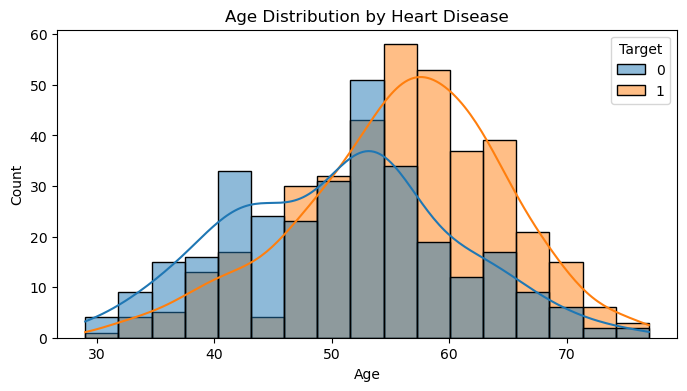

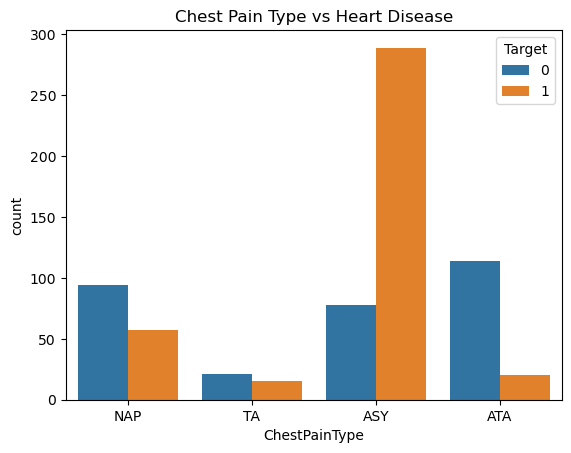

In [4]:
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Verteilung des Alters vs. Herzerkrankung
plt.figure(figsize=(8, 4))
sns.histplot(data=X_train.assign(Target=y_train), x='Age', hue='Target', kde=True)
plt.title('Age Distribution by Heart Disease')
plt.show()

# Brustschmerztyp vs. Herzerkrankung
sns.countplot(data=X_train.assign(Target=y_train), x='ChestPainType', hue='Target')
plt.title('Chest Pain Type vs Heart Disease')
plt.show()

# 4. Encoding

In [5]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Spalten definieren
cat_ohe = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina']
cat_ord = ['ST_Slope'] # Aufwärtshang/Flach/Abwärtshang hat eine inhärente Reihenfolge
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# Transformer einrichten
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_ohe),
    ('ord', OrdinalEncoder(categories=[['Down', 'Flat', 'Up']]), cat_ord)
], remainder='passthrough')

# Anpassen und transformieren
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# 5. Furhter data preprocessing

In [6]:
# Optional: Skalierung (nicht unbedingt erforderlich)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_proc = scaler.fit_transform(X_train_proc)
X_test_proc = scaler.transform(X_test_proc)

# 6. Train and evaluate RF using CV on X_train  

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(random_state=12)
cv_scores = cross_val_score(rf_cv, X_train_proc, y_train, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV Accuracy: 0.8518 (+/- 0.0173)


# 7. Train a model using the best combination of hyperparameters and preprocessing

In [8]:
from sklearn.model_selection import GridSearchCV

# Einfache Hyperparameter-Abstimmung
params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
grid = GridSearchCV(RandomForestClassifier(random_state=12), params, cv=5)
grid.fit(X_train_proc, y_train)

# Vorhersagen auf X_test
y_pred = grid.best_estimator_.predict(X_test_proc)
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 200}


# 8. Check how well your model performs on unseen data finally using y_test

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test = pd.read_csv('y_test.csv', index_col=0)['HeartDisease']

# Vergleichen Sie mit den Vorhersagen (y_pred) aus Schritt 7
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final Test Accuracy: 0.9043

Confusion Matrix:
[[ 92  11]
 [ 11 116]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       103
           1       0.91      0.91      0.91       127

    accuracy                           0.90       230
   macro avg       0.90      0.90      0.90       230
weighted avg       0.90      0.90      0.90       230

